# FR05 — Neftin dünya bazarında qiymətinin proqnozlaşdırılması

## 1. Tələb

**Tələb (MİİS §15.5.1, FR5).** «Neftin dünya bazarında qiymətinin proqnozlaşdırılması.»
Hüquqi əsas: Nazirlər Kabinetinin 24.05.2004 tarixli 75 nömrəli qərarı, bənd 2.4.1.

Bu dəftər paketin **yeganə neft qiyməti yolunu** hazırlayır. Neftin dünya qiyməti Azərbaycan
iqtisadiyyatının modelində sadəcə bir göstərici deyil, təməl sürücü kəmiyyətdir: neft-qaz
sektorunun nominal həcmi, malların ixracının dəyəri, cari hesabın saldosu və dolayısı ilə
büdcə gəlirləri ondan asılıdır. Ona görə qiymət burada bir dəfə modelləşdirilir, nəticə
`data/assumptions.csv` faylına `brent_usd` açarı ilə yazılır, aşağı axın bölmələri (FR1, FR7,
FR9, FR11, FR12) isə həmin faylı oxuyur; paketdə ikinci neft qiyməti yolu yoxdur və heç bir
tənlikdə qiymət ədədi kimi yazılmır.

Nazirliyin öz Proqnoz sütunu (sabit 65 USD/barel) və əvvəlki təhvildə istifadə olunmuş
fərziyyə (90 → 78 USD/barel) yalnız **müqayisə** üçün göstərilir; nə qiymətləndirmə nümunəsinə,
nə də mərkəzi yola daxil edilir.

In [1]:
import os
import sys

# dəftər həm depo kökündən, həm də notebooks/ qovluğundan işlədilə bilər
_root = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, os.path.join(_root, "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

import config
import data_layer
import econometrics as ek
import outputs
import validate

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True, "grid.alpha": 0.30,
                     "font.size": 10, "axes.titlesize": 11, "figure.dpi": 110})

FY = list(config.FY)          # 2026–2030 — proqnoz üfüqü mərkəzi konfiqurasiyadan gəlir
FR = "FR5"
print(f"son faktiki il: {config.LAST_ACTUAL}   proqnoz üfüqü: {FY[0]}–{FY[-1]}")

son faktiki il: 2025   proqnoz üfüqü: 2026–2030


## 2. Məlumat

| Sıra | Kod | Əhatə | Mənbə |
|---|---|---|---|
| Brent markalı neftin qiyməti, illik orta | `brent_usd` | 1991–2025 | Neft-Qaz sektoru, sətir 11 (eia.gov); 1991–1994 `macro_annual.csv` |
| Azərbaycan neftinin ixrac qiyməti | `oil_export_price` | 1997–2025 | Neft-Qaz sektoru, sətir 10 (DGK) |
| Brent, aylıq spot | `monthly_panel.csv → brent`; 2025 üçün Neft-Qaz sektoru, sətir 11 | 1995-01 – 2025-12 | aylıq panel + bərpa |
| Ticarət tərəfdaşlarının real ÜDM artımı | `partner_gdp_realg` | 2000–2030 | `external_block_annual.csv` (IMF WEO) |
| Şablon-nümunə ssenarisi | `ministry_baseline('brent_usd')` | 2026–2030 | 8 vərəq, 2.4.1.5.-7., sətir 4 |
| Köhnə fərziyyə (müqayisə) | `macro_annual.csv → oil_price_usd` | 2026–2030 | əvvəlki təhvil |

İki aylıq mənbə arasındakı fərq izah tələb edir. İş kitabının aylıq sətri (Neft-Qaz sektoru, 11)
**ilin əvvəlindən yığılmış orta** kimi aparılır — hər ilin dekabr xanası həmin ilin illik orta
qiymətinə bərabərdir, ona görə bu sətrin xanaları **birbaşa** aylıq qiymət kimi oxuna bilməz.
Dalğalanmanın əsas mənbəyi buna görə `monthly_panel.csv` faylının spot sırasıdır; onun illik
ortası iş kitabının illik göstəricisini ən çoxu 0,76 USD fərqlə təkrarlayır (aşağıda yoxlanılır).

Həmin panel isə 2024-12-də bitir, yəni son faktiki il (2025) kalibrləmədən kənarda qalırdı. Boşluq
bağlanır: 2025-ci ilin ayları iş kitabının 11-ci sətrindən **bərpa olunur** — yığılmış orta
tərifinə görə ayın öz qiyməti $m_t = t\,c_t - (t-1)\,c_{t-1}$ eyniliyindən çıxır. Bu, uydurma sıra
deyil, mövcud sətrin tərifinin tərsidir; düzgünlüyü 2021–2024 **üst-üstə düşən** dövründə panelin
faktiki spot qiymətləri ilə yoxlanılır və bərpa olunmuş 12 ayın ortası illik sıranın 2025 xanası
ilə tutuşdurulur. Panelin öz illəri toxunulmaz qalır — bərpa yalnız boşluğu doldurur.

Ticarət tərəfdaşlarının artım tempi dünya tələbinin göstəricisi kimi işlədilir. Onun
2026–2030 dəyərləri IMF WEO proyeksiyasıdır — xarici, provenansı açıq göstərilən girişdir və
Nazirliyin Proqnoz sütunu ilə əlaqəsi yoxdur.

In [2]:
# --- əsas sıralar (data_layer həmişə ≤ LAST_ACTUAL qaytarır) --------------------------------
brent = data_layer.actuals("brent_usd")                 # illik orta, USD/barel
xprice = data_layer.actuals("oil_export_price")         # Azərbaycan neftinin ixrac qiyməti
ln_brent = np.log(brent).rename("ln_brent")             # model loq səviyyədə qurulur
d_ln_brent = ln_brent.diff().dropna().rename("d_ln_brent")

# --- dünya tələbinin göstəricisi: tərəfdaş ölkələrin real ÜDM artımı (IMF WEO) ---------------
_ext = data_layer.external_block().set_index("year")
pg_all = _ext["partner_gdp_realg"].dropna()
pg_act = pg_all[pg_all.index <= config.LAST_ACTUAL]                    # qiymətləndirmə üçün
pg_fut = pg_all[(pg_all.index >= FY[0]) & (pg_all.index <= FY[-1])]    # üfüq üçün — WEO proyeksiyası

# --- aylıq spot sıra: yalnız dalğalanmanın ölçülməsi üçün ------------------------------------
# `monthly_panel.csv` 2024-12-də bitir, ona görə köhnə buraxılışda σ-nın kalibrləməsi SON FAKTİKİ
# İLİ (2025) əhatə etmirdi. Boşluq iş kitabının 11-ci sətrindən bağlanır: həmin sətir ilin
# əvvəlindən YIĞILMIŞ ORTA olduğuna görə ayın öz qiyməti eyniliklə bərpa olunur —
#     m_t = t·c_t − (t−1)·c_{t−1},   m_1 = c_1
# Bərpa uydurma deyil, eyniliyin tərsidir; düzgünlüyü 2021–2024 ÜST-ÜSTƏ DÜŞƏN dövründə panelin
# öz faktiki spot sırası ilə yoxlanılır (aşağıda çap olunur) və yalnız bundan sonra 2025-ci ilin
# ayları panelə əlavə edilir. Panelin mövcud illəri toxunulmaz qalır — bərpa YALNIZ boşluğu doldurur.
_mp = pd.read_csv(config.P_MONTHLY, usecols=["date", "brent"]).dropna()
_mp["year"] = _mp["date"].str.slice(0, 4).astype(int)
_panel_m = _mp[_mp["year"] <= config.LAST_ACTUAL]

_cum = data_layer.monthly("oilgas_r011").set_index(["year", "month"])["value"]   # yığılmış orta
_rec = []
for _y in sorted({y for y, _ in _cum.index}):
    _c = _cum.loc[_y]
    for _m in sorted(_c.index):
        _v = float(_c.loc[_m]) if _m == 1 else _m * float(_c.loc[_m]) - (_m - 1) * float(_c.loc[_m - 1])
        _rec.append({"date": f"{_y}-{_m:02d}", "brent": _v, "year": int(_y)})
_rec = pd.DataFrame(_rec)

# bərpa üsulunun yoxlanışı — panelin faktiki spot sırası ilə üst-üstə düşən illər
_ov = _rec.merge(_panel_m[["date", "brent"]], on="date", suffixes=("_bərpa", "_panel"))
_ov_err = (_ov["brent_bərpa"] - _ov["brent_panel"]).abs()

_fill = _rec[(_rec["year"] > int(_panel_m["year"].max())) & (_rec["year"] <= config.LAST_ACTUAL)]
brent_m = pd.concat([_panel_m[["date", "brent", "year"]], _fill[["date", "brent", "year"]]],
                    ignore_index=True).sort_values("date").reset_index(drop=True)

# --- müqayisə ssenariləri (heç bir tənliyə daxil edilmir) ------------------------------------
tmpl_brent = data_layer.ministry_baseline("brent_usd").reindex(FY)     # şablon-nümunə: sabit 65
old_brent = pd.read_csv(config.P_MACRO).set_index("year")["oil_price_usd"].reindex(FY)  # köhnə: 90→78

print(f"brent_usd: {brent.index.min()}–{brent.index.max()}, n = {len(brent)}, "
      f"2025 = {brent.iloc[-1]:.2f} USD/barel")
print(f"oil_export_price: {xprice.index.min()}–{xprice.index.max()}, n = {len(xprice)}")
print(f"partner_gdp_realg (faktiki): {pg_act.index.min()}–{pg_act.index.max()}, n = {len(pg_act)}")
print(f"aylıq spot: {brent_m['date'].iloc[0]} – {brent_m['date'].iloc[-1]}, n = {len(brent_m)} "
      f"(paneldən {len(_panel_m)}, iş kitabından bərpa {len(_fill)})")
print(f"  bərpa üsulunun yoxlanışı ({_ov['date'].min()}–{_ov['date'].max()}, n = {len(_ov)}): "
      f"maksimal fərq {_ov_err.max():.2f} USD, korrelyasiya "
      f"{_ov['brent_bərpa'].corr(_ov['brent_panel']):.4f}")
print(f"şablon-nümunə ssenarisi 2026–2030: {tmpl_brent.round(1).tolist()}")
print(f"köhnə fərziyyə 2026–2030: {old_brent.round(1).tolist()}")

# aylıq spot sıranın illik ortası iş kitabının illik göstəricisi ilə tutuşdurulur (provenans
# yoxlaması). Bu, həm də bərpanın müstəqil sınağıdır: 2025-ci ilin bərpa olunmuş 12 ayının
# ortası illik sıranın 2025 xanasına bərabər çıxmalıdır.
_ann_from_m = brent_m.groupby("year")["brent"].mean()
_cmp = pd.DataFrame({"aylıqdan illik orta": _ann_from_m, "illik sıra": brent}).dropna()
print(f"\naylıq panel ↔ illik sıra: {len(_cmp)} il, maksimal fərq "
      f"{(_cmp['aylıqdan illik orta'] - _cmp['illik sıra']).abs().max():.3f} USD")
display(brent.tail(10).round(2).to_frame("brent_usd, USD/barel").T)

brent_usd: 1991–2025, n = 35, 2025 = 69.14 USD/barel
oil_export_price: 1997–2025, n = 29
partner_gdp_realg (faktiki): 2000–2025, n = 26
aylıq spot: 1995-01 – 2025-12, n = 372 (paneldən 360, iş kitabından bərpa 12)
  bərpa üsulunun yoxlanışı (2021-01–2024-12, n = 48): maksimal fərq 1.98 USD, korrelyasiya 0.9996
şablon-nümunə ssenarisi 2026–2030: [65.0, 65.0, 65.0, 65.0, 65.0]
köhnə fərziyyə 2026–2030: [90.0, 84.0, 80.0, 78.0, 78.0]

aylıq panel ↔ illik sıra: 31 il, maksimal fərq 0.757 USD


year,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
"brent_usd, USD/barel",43.64,54.13,71.34,64.3,41.96,70.86,100.93,82.49,80.52,69.14


## 3. Model seçimi

Qiymət **loq səviyyədə** modelləşdirilir: göstərici müsbətdir, şoklar isə nisbi (faizlə) təsir
göstərir, ona görə loq fərq iqtisadi mənası olan kəmiyyətdir və qalıqların dispersiyası səviyyə
boyu sabit qalır. Beş namizəd müqayisə olunur:

1. **RW — təsadüfi gəzişmə (etalon).** $\ln P_t = \ln P_{t-1} + \varepsilon_t$. Xam mal
   bazarlarında bu spesifikasiya nəzəri gözləntidir: cari qiymət gələcək qıtlıq haqqında mövcud
   bütün məlumatı özündə saxlayır, ona görə növbəti ilin ən yaxşı proqnozu bu ilin qiymətidir.
2. **RW + sürüşmə (drift).** Sabit orta artım əlavə olunur; 1991–2025 nümunəsində bu, uzun
   dövrün orta illik qiymət artımını gələcəyə uzadır.
3. **AR(1) — orta qiymətə qayıdış.** $\ln P_t = c + \varphi \ln P_{t-1} + \varepsilon_t$;
   $\varphi < 1$ olduqda qiymət uzunmüddətli ortaya qayıdır. Bu spesifikasiya təklif tərəfinin
   uyğunlaşmasını (yüksək qiymət → yeni hasilat → qiymətin geri çəkilməsi) qısaldılmış formada
   əks etdirir.
4. **STRUKTUR (şərti) — dünya tələbi tənliyi.** $\Delta \ln P_t = \alpha + \beta\, g^{\text{tərəfdaş}}_t
   + \varepsilon_t$. Neftin qiyməti qısa üfüqdə əsasən tələb şokları ilə hərəkət edir: 2009 və
   2020-ci illərdə dünya iqtisadiyyatının yığılması qiyməti üçdə bir azaltmış, 2021-ci ildə
   bərpa onu qaldırmışdır. Tərəfdaş ölkələrin real ÜDM artımı bu şokun paketdə mövcud olan
   yeganə ölçüsüdür.
5. **STRUKTUR-gecikmə (şərtsiz).** Eyni tənlik, lakin cari il əvəzinə keçən ilin tərəfdaş artımı
   ilə: $\Delta \ln P_t = \alpha + \beta\, g^{\text{tərəfdaş}}_{t-1} + \varepsilon_t$. Bu variant
   proqnozçunun proqnoz anında faktiki malik olduğu məlumat dəstini əks etdirir.

Təklif tərəfinin (OPEC+ kvotaları, ehtiyat həcmləri, kəşfiyyat xərcləri) modelləşdirilməsi
nəzərdə tutulmur: bu göstəricilər nə iş kitabında, nə də statutar şablonda mövcud deyil, uydurma
sıralar isə paketə daxil edilmir. Buna görə struktur tənlik tələb tərəfinin qısaldılmış forması
kimi qurulur.

Bir metodoloji ayrım əvvəlcədən qeyd olunur. 4-cü namizəd cari ilin tərəfdaş artımını tələb
etdiyi üçün onun proqnozu **şərtidir**: nəticə IMF WEO-nun dünya artımı proyeksiyasının doğru
çıxmasından asılıdır; 5-ci namizəd isə yalnız keçmiş məlumatla işləyir. Aşağıdakı sınaqda hər iki
variant ayrıca yoxlanılır — belə olmasa, sınaq nəticəsi proqnozçunun real vəziyyətini deyil, ona
verilmiş əlavə məlumatı ölçərdi.

İkinci ayrım əmsalın şərhinə aiddir. Tərəfdaş ölkələrin artımı neft qiymətindən müstəqil deyil —
qiymət şoku özü də dünya artımına təsir edir — ona görə OLS əmsalı səbəbiyyət parametri kimi
oxuna bilməz. Tənlik burada **qısaldılmış forma** kimi qurulur və nəticələr 9-cu bölmədə məhz bu
qeydlə verilir.

## 4. Testlər

Əvvəlcə inteqrasiya dərəcəsi müəyyən edilir: qiymət səviyyəsində vahid kök varsa, tənlik fərqlər
üzrə qurulmalıdır. Ardınca Brent ilə Azərbaycan neftinin ixrac qiyməti arasındakı uzunmüddətli
əlaqə **yalnız** Engle–Granger kointeqrasiya sınağı ilə (MacKinnon kritik qiymətləri) yoxlanılır;
qalıqlar üzərində adi ADF p-qiyməti heç bir yerdə istifadə olunmur.

In [3]:
adf_lvl = ek.adf(ln_brent, name="ln Brent (səviyyə)")
adf_trd = ek.adf(ln_brent, name="ln Brent (səviyyə, trendli)", regression="ct")
adf_dif = ek.adf(d_ln_brent, name="Δln Brent")
for r in (adf_lvl, adf_trd, adf_dif):
    print(r)

# ln səviyyədə vahid kök rədd edilmir, birinci fərqdə stasionarlıq təsdiqlənir → tənlik Δln üzərində
print("\n" + adf_lvl.note_az)
print(adf_dif.note_az)

# Brent ↔ ixrac qiyməti: uzunmüddətli əlaqənin MÖVCUDLUĞU yalnız eg_coint ilə yoxlanılır
# (MacKinnon cədvəlləri); qalıqlar üzərində adi ADF p-qiyməti heç bir yerdə istifadə olunmur
_lx = np.log(xprice).rename("ln_xprice")
_lb = ln_brent.reindex(_lx.index).rename("ln_brent")
_pair = pd.concat([_lx, _lb], axis=1).dropna()
ct = ek.eg_coint(_pair["ln_xprice"], _pair[["ln_brent"]], name="ln ixrac qiyməti ~ ln Brent")
print("\n" + str(ct))

# Uzunmüddətli elastikliyin QİYMƏTİ isə DOLS (Stock–Watson) ilə hesablanır. Səbəb: kointeqrasiya
# reqressiyasında statik OLS-in HAC standart xətaları asimptotik olaraq ETİBARLI DEYİL —
# reqressor endogendir və qalıqlar avtokorrelyasiyalıdır, bu isə ikinci dərəcəli meyl yaradır.
# DOLS reqressorun aparıcı və gecikməli fərqlərini əlavə edib bu meyli aradan qaldırır, beləliklə
# β üzərində standart t sınağı qanuni olur.
#
# BİR SEÇİM AÇIQ EDİLİR. Aparıcı fərq (lead) 2026-cı ilin Δln Brent-ini tələb edir, o isə yoxdur,
# ona görə lead-li spesifikasiya SON FAKTİKİ İLİ (2025) nümunədən çıxarır. Hesabat tənliyi buna
# görə YALNIZ gecikməli fərqlə qurulur — nümunə 1997–2025, n = 29, yəni 2025 daxildir. Lead-li
# variant isə robustluq sətri kimi ayrıca verilir; iki qiymətləndirmə arasındakı fərq əmsalın
# standart xətasından kiçikdir, ona görə seçim nəticəni dəyişmir.
def _dols_fit(lead: bool, ad: str):
    _cols = {"ln_xprice": _pair["ln_xprice"], "ln_brent": _pair["ln_brent"]}
    if lead:
        _cols["d_lead"] = d_ln_brent.shift(-1)
    _cols["d_cari"] = d_ln_brent
    _cols["d_gecikme"] = d_ln_brent.shift(1)
    _df = pd.DataFrame(_cols).dropna()
    return ek.ols_hac(_df["ln_xprice"], _df[[c for c in _df.columns if c != "ln_xprice"]],
                      maxlags=2, name=ad, verbose=False)

lr_x = _dols_fit(False, "ixrac qiyməti — uzunmüddətli əlaqə (DOLS, 2025 daxil)")
lr_x_lead = _dols_fit(True, "DOLS + aparıcı fərq (robustluq, 2025 xaric)")
print(lr_x)

# «Bir-bir keçid» ifadəsi yalnız β = 1 sınağı rədd edilmədikdə işlədilə bilər — ona görə sınaq
# göz qabağında aparılır və nəticəsi 4-cü bölmənin şərhinə birbaşa daxil olur.
_be, _sb = float(lr_x.params["ln_brent"]), float(lr_x.se["ln_brent"])
_tt1 = lr_x.fit.t_test("ln_brent = 1")
print(f"  → β = {_be:.3f} (HAC s.x. {_sb:.3f}); 95% interval "
      f"[{_be - 1.96 * _sb:.2f}, {_be + 1.96 * _sb:.2f}]")
print(f"  → H₀: β = 1 (vahid keçid): t = {float(np.squeeze(_tt1.tvalue)):.2f}, "
      f"p = {float(np.squeeze(_tt1.pvalue)):.3f} → RƏDD EDİLİR "
      f"(ixrac qiyməti Brent-ə vahiddən bir qədər YÜKSƏK elastikliklə bağlıdır)")

# spesifikasiya robustluğu: son ilin daxil/xaric olması əmsalı dəyişmir
_rob = []
for _r in (lr_x, lr_x_lead):
    _b, _s = float(_r.params["ln_brent"]), float(_r.se["ln_brent"])
    _t = _r.fit.t_test("ln_brent = 1")
    _rob.append({"spesifikasiya": _r.name, "n": _r.n,
                 "nümunə": f"{_r.sample[0]}–{_r.sample[1]}", "β": round(_b, 4),
                 "HAC s.x.": round(_s, 4), "t (β=1)": round(float(np.squeeze(_t.tvalue)), 2),
                 "p": round(float(np.squeeze(_t.pvalue)), 3)})
print()
print(pd.DataFrame(_rob).to_string(index=False))
print(f"  → iki variant arasındakı fərq {abs(_rob[0]['β'] - _rob[1]['β']):.4f}, "
      f"HAC s.x.-dən ({_rob[0]['HAC s.x.']:.4f}) kiçikdir → nəticə son ilin daxil edilməsinə "
      f"və lead seçiminə həssas deyil")


ADF[ln Brent (səviyyə)] stat=-1.367 p=0.5979 lag=0 n=34 kritik(1%: -3.64, 10%: -2.61, 5%: -2.95) → vahid kök
ADF[ln Brent (səviyyə, trendli)] stat=-1.817 p=0.6963 lag=0 n=34 kritik(1%: -4.25, 10%: -3.21, 5%: -3.55) → vahid kök
ADF[Δln Brent] stat=-5.621 p=0.0000 lag=1 n=32 kritik(1%: -3.65, 10%: -2.62, 5%: -2.96) → stasionar

ADF (ln Brent (səviyyə)): vahid kök rədd edilmir (p = 0.598, n = 34, gecikmə = 0) → səviyyədə qeyri-stasionar.
ADF (Δln Brent): vahid kök rədd edilir (p = 0.000, n = 32, gecikmə = 1) → stasionar.

EG-coint[ln ixrac qiyməti ~ ln Brent] stat=-5.147 p=0.0001 n=29 k=1 kritik(1%: -4.33, 10%: -3.20, 5%: -3.56) → kointeqrasiya var
OLS+HAC[ixrac qiyməti — uzunmüddətli əlaqə (DOLS, 2025 daxil)]  n=29  nümunə=1997–2025  HAC gecikmə=2
  R²=0.979  düzəldilmiş R²=0.976  reqressiyanın s.x.=0.1079
  dəyişən                əmsal    HAC s.x.        t        p
  const                -0.6807      0.2596    -2.62    0.009
  ln_brent              1.1549      0.0615    18.78    0.000
 

Nəticə. `ln Brent` səviyyədə qeyri-stasionardır (sabitli spesifikasiyada p = 0,598; trendli
spesifikasiyada p = 0,696), birinci fərqdə isə stasionarlıq güclü şəkildə təsdiqlənir
(p < 0,001). Ona görə bütün tənliklər Δln səviyyəsində qurulur, AR(1) isə səviyyə üçün ayrıca
namizəd kimi saxlanılır (φ-nin 1-dən kiçik olub-olmaması sınaqda yoxlanılır).

Brent ilə Azərbaycan neftinin ixrac qiyməti arasında kointeqrasiya təsdiqlənir (EG statistikası
−5,15, p = 0,0001, n = 29). Uzunmüddətli elastiklik **DOLS** ilə qiymətləndirilir: kointeqrasiya
reqressiyasında statik OLS-in HAC standart xətaları asimptotik olaraq etibarlı olmadığı üçün β
üzərində heç bir sınaq həmin tənlikdən çıxarıla bilməz. Hesabat tənliyi **son faktiki ili saxlayan**
spesifikasiyadır (yalnız gecikməli fərq; aparıcı fərq 2026-cı ilin məlumatını tələb edərdi və
nümunəni 2024-də kəsərdi): β = 1,155 (HAC s.x. 0,062; n = 29, nümunə **1997–2025**), 95 % interval
[1,03; 1,28]. Aparıcı fərqli variant robustluq sətri kimi verilir — β = 1,174 (n = 28, 1997–2024);
iki qiymətləndirmə arasındakı fərq 0,019, yəni əmsalın öz standart xətasından kiçikdir, ona görə
nəticə nə son ilin daxil edilməsinə, nə də lead seçiminə həssasdır.

**Bir hərfi dəqiqləşdirmə.** Stock–Watson DOLS prosedurunun asimptotik əsası reqressorun **həm
aparıcı, həm gecikməli** fərqlərinin daxil edilməsinə söykənir. Hesabat tənliyi son faktiki ili
saxlamaq üçün aparıcı fərqi ATIR, yəni meyl düzəlişi **qismən**dir; ona görə «DOLS» adı burada
prosedurun tam formasını deyil, onun gecikməli variantını bildirir. Praktik nəticəyə təsiri
yoxdur: β = 1 hipotezi hər iki spesifikasiyada eyni gücdə rədd olunur (lead-siz t = 2,52,
p = 0,012; lead-li t = 2,54, p = 0,011), yəni vahiddən yüksək keçid nəticəsi spesifikasiya
seçimindən asılı deyil.

Deməli keçid vahiddən bir qədər **yüksəkdir** və H₀: β = 1 rədd edilir (t = 2,52, p = 0,012):
Brent 1 % bahalaşdıqda Azərbaycan neftinin ixrac qiyməti təxminən 1,15 % bahalaşır. Bu, «bir-bir
izləyir» ifadəsindən fərqlidir, lakin paketin qurulma məntiqini dəyişmir — əlaqə sabit və sıxdır
(R² = 0,979), ona görə xarici sektor bloku üçün **bir** dünya qiyməti yolu kifayətdir və ixrac
qiyməti ayrıca proqnozlaşdırılmır.

## 5. Qiymətləndirmə

Üç tənlik qiymətləndirilir; hər biri OLS və Newey–West (HAC) standart xətaları ilə. Nümunənin
yuxarı sərhədi bütün tənliklərdə `config.LAST_ACTUAL` = 2025-dir — proqnoz üfüqünün heç bir dəyəri
reqressiyaya daxil ola bilmir, bu, `econometrics.ols_hac` funksiyasının struktur mühafizəsidir.
Aşağı sərhəd isə məlumatın başlanğıcı ilə müəyyən olunur və tənliklər üzrə fərqlidir: sürüşmə və
AR(1) üçün 1992–2025 (loq fərq bir il itirir), struktur tənlik üçün 2000–2025 (tərəfdaş ölkələrin
artım sırası 2000-ci ildən başlayır).

In [4]:
# (1) ETALON: sürüşmə (drift) — Δln P-nin sabiti; sıfırdan fərqli olub-olmaması yoxlanılır
_one = pd.DataFrame({"const": 1.0}, index=d_ln_brent.index)
res_drift = ek.ols_hac(d_ln_brent, _one, add_const=False, maxlags=1, name="Δln Brent — sürüşmə")
print(res_drift, "\n")

# (2) ETALON: AR(1) loq səviyyədə — orta qiymətə qayıdış
_ar = pd.concat([ln_brent.rename("y"), ln_brent.shift(1).rename("ln_brent_l1")], axis=1).dropna()
res_ar1 = ek.ols_hac(_ar["y"], _ar[["ln_brent_l1"]], maxlags=1, name="ln Brent — AR(1)")
print(res_ar1)
_phi = float(res_ar1.params["ln_brent_l1"])
# Diqqət: c/(1−φ) ln P-nin uzunmüddətli ortasıdır, ona görə onun eksponentı SƏVİYYƏNİN medianıdır
# (həm də həndəsi ortası), riyazi gözləməsi deyil — loq-normal düzəliş qəsdən edilmir.
_mu = float(np.exp(res_ar1.params["const"] / (1.0 - _phi)))
print(f"  → uzunmüddətli səviyyə (median) = exp(c/(1−φ)) = {_mu:.1f} USD/barel; "
      f"yarım-ömür = {np.log(0.5) / np.log(_phi):.1f} il\n")

# (3) STRUKTUR (əsas) tənlik: dünya tələbi
_st = pd.concat([d_ln_brent.rename("d"), pg_act.rename("partner_g")], axis=1).dropna()
res_str = ek.ols_hac(_st["d"], _st[["partner_g"]], maxlags=1, name="Δln Brent ~ tərəfdaş ÜDM artımı")
print(res_str)
_a, _b = float(res_str.params["const"]), float(res_str.params["partner_g"])

# Neytral tərəfdaş artımı θ = −α/β mərkəzi yolun BÜTÜN formasını müəyyən edir: qiymət yalnız
# faktiki artım θ-dan yuxarı olduqda qalxır. θ iki qiymətləndirmənin nisbəti olduğu üçün onun öz
# qeyri-müəyyənliyi ayrıca verilməlidir — əks halda yolun düz çıxması səhvən «dəqiq» oxunur.
_C_str = res_str.cov_params.reindex(index=["const", "partner_g"],
                                    columns=["const", "partner_g"]).values
_theta = -_a / _b
_grad = np.array([-1.0 / _b, _a / _b ** 2])          # ∂θ/∂(α, β) — delta üsulu
_se_theta = float(np.sqrt(_grad @ _C_str @ _grad))
print(f"  → neytral tərəfdaş artımı (Δln P = 0): θ = {_theta:.2f} % "
      f"(delta üsulu ilə s.x. {_se_theta:.2f} f.b.)")
print(f"     95% interval: [{_theta - 1.96 * _se_theta:.2f}, {_theta + 1.96 * _se_theta:.2f}] % "
      f"— WEO-nun 2026–2030 aralığı ({pg_fut.min():.2f}–{pg_fut.max():.2f} %) bu intervalın "
      f"içindədir, yəni yolun düz çıxması θ-nın DƏQİQ bilinməsindən irəli gəlmir")

[OLS+HAC] Δln Brent — sürüşmə: n=34, nümunə=1992–2025, R²=-0.000, düzəldilmiş R²=-0.000, s.x.=0.2769
OLS+HAC[Δln Brent — sürüşmə]  n=34  nümunə=1992–2025  HAC gecikmə=1
  R²=-0.000  düzəldilmiş R²=-0.000  reqressiyanın s.x.=0.2769
  dəyişən                əmsal    HAC s.x.        t        p
  const                 0.0364      0.0488     0.75    0.455 

[OLS+HAC] ln Brent — AR(1): n=34, nümunə=1992–2025, R²=0.844, düzəldilmiş R²=0.839, s.x.=0.2733
OLS+HAC[ln Brent — AR(1)]  n=34  nümunə=1992–2025  HAC gecikmə=1
  R²=0.844  düzəldilmiş R²=0.839  reqressiyanın s.x.=0.2733
  dəyişən                əmsal    HAC s.x.        t        p
  const                 0.3918      0.2557     1.53    0.126
  ln_brent_l1           0.9059      0.0673    13.47    0.000
  → uzunmüddətli səviyyə (median) = exp(c/(1−φ)) = 64.2 USD/barel; yarım-ömür = 7.0 il

[OLS+HAC] Δln Brent ~ tərəfdaş ÜDM artımı: n=26, nümunə=2000–2025, R²=0.492, düzəldilmiş R²=0.471, s.x.=0.2148
OLS+HAC[Δln Brent ~ tərəfdaş ÜDM artımı]  

In [5]:
display(Markdown(
    r"$\widehat{\Delta \ln P_t} = " + f"{_a:.4f}" + r"\;+\;" + f"{_b:.4f}" +
    r"\, g^{\mathrm{tərəfdaş}}_t$" + "  \n"
    r"$\qquad(\text{HAC s.x.})\quad" + f"({res_str.se['const']:.4f})" +
    r"\qquad\quad" + f"({res_str.se['partner_g']:.4f})$" + "  \n"
    f"$n = {res_str.n}$, nümunə {res_str.sample[0]}–{res_str.sample[1]}, "
    f"düzəldilmiş $R^2 = {res_str.adj_r2:.3f}$, reqressiyanın s.x. $= {res_str.sigma:.4f}$"
))

$\widehat{\Delta \ln P_t} = -0.2009\;+\;0.0809\, g^{\mathrm{tərəfdaş}}_t$  
$\qquad(\text{HAC s.x.})\quad(0.0589)\qquad\quad(0.0111)$  
$n = 26$, nümunə 2000–2025, düzəldilmiş $R^2 = 0.471$, reqressiyanın s.x. $= 0.2148$

### 5.1 Robustlik

Struktur tənliyin əmsalı böyük ölçüdə üç müşahidə ilə müəyyən olunur: 2009 (dünya artımı −2,5 %,
qiymət −36 %), 2020 (−5,0 %, −35 %) və 2021 (+8,6 %, +69 %). Bu, tənliyin zəifliyi deyil,
məzmunudur — neft qiymətinin böyük hərəkətləri məhz belə illərdə baş verir — lakin əmsalın nə
qədər həssas olduğu açıq göstərilməlidir. Üç yoxlama aparılır; ilk ikisi **eyni üç ili** hədəf
alır ki, nəticələri müqayisə oluna bilsin: (i) həmin illər üçün süni dəyişən (dummy) əlavə edilir
— 2009/2020 yığılma, 2021 isə bərpa olduğuna, yəni əks işarə daşıdığına görə onlar bir dummy-də
birləşdirilmir, iki ayrı dummy götürülür; (ii) həmin üç il nümunədən tamamilə çıxarılır.
Üçüncü yoxlama ayrı bir sualı ölçür: **son faktiki il (2025)** həm nümunənin sonuncu müşahidəsi,
həm də proqnozun başlanğıc nöqtəsidir, ona görə əmsalları tək başına sürükləyib-sürükləmədiyi
göstərilməlidir — bütün əsas tənliklər 2025 daxil və xaric yenidən qiymətləndirilir.

In [6]:
# Böhran illəri üçün süni dəyişənlər. DİQQƏT: 2009/2020 (yığılma) və 2021 (bərpa) əks
# işarəlidir, ona görə onları BİR dummy-də birləşdirmək olmaz — iki ayrı dummy götürülür.
# Beləliklə dummy spesifikasiyası ilə aşağıdakı «çıxarılmış nümunə» yoxlaması EYNİ üç ili
# əhatə edir və iki sınaq həqiqətən müqayisə oluna bilir (n = 26, k = 4 — yer var).
_X2 = _st[["partner_g"]].copy()
_X2["kriz_09_20"] = np.where(_st.index.isin([2009, 2020]), 1.0, 0.0)
_X2["berpa_21"] = np.where(_st.index == 2021, 1.0, 0.0)
res_dum = ek.ols_hac(_st["d"], _X2, maxlags=1,
                     name="Δln Brent ~ tərəfdaş artımı + böhran/bərpa dummy-ləri")
print(res_dum)
_F = res_dum.fit.f_test("kriz_09_20 = 0, berpa_21 = 0")
print(f"  → birgə sınaq H₀: hər iki dummy = 0 → F = {float(np.squeeze(_F.fvalue)):.2f}, "
      f"p = {float(np.squeeze(_F.pvalue)):.3f}")
print(f"  → neytral tərəfdaş artımı (dummy-li) = "
      f"{-res_dum.params['const'] / res_dum.params['partner_g']:.2f} %\n")

# Həmin üç il nümunədən tamamilə çıxarıldıqda (həssaslıq yoxlaması, hesabat tənliyi deyil)
_kriz_iller = (2009, 2020, 2021)
_keep = [y for y in _st.index if y not in _kriz_iller]
res_nokriz = ek.ols_hac(_st.loc[_keep, "d"], _st.loc[_keep, ["partner_g"]], maxlags=1,
                        name="Δln Brent ~ tərəfdaş artımı (böhransız nümunə)")
print(res_nokriz)
# `sample` yalnız indeksin uc illərini göstərir; çıxarılmış illər ayrıca yazılır ki, n = 23-ün
# haradan gəldiyi cədvəldən oxunsun
print(f"  → nümunədən çıxarılan illər: {list(_kriz_iller)} (n = {res_nokriz.n})")
print(f"  → neytral tərəfdaş artımı (böhransız) = "
      f"{-res_nokriz.params['const'] / res_nokriz.params['partner_g']:.2f} %\n")

# Üçüncü yoxlama: SON FAKTİKİ İLİN (2025) tənliyə təsiri. 2025 nümunənin sonuncu müşahidəsidir
# və proqnozun başlanğıc nöqtəsidir, ona görə onun əmsalı sürükləyib-sürükləmədiyi açıq
# göstərilir — bütün əsas tənliklər 2025 daxil və xaric yenidən qiymətləndirilir.
_rows_25 = []
for _lab, _idx in [("2000–2025 (hesabat)", _st.index),
                   ("2000–2024 (2025 xaric)", _st.index[_st.index <= config.LAST_ACTUAL - 1])]:
    _r = ek.ols_hac(_st.loc[_idx, "d"], _st.loc[_idx, ["partner_g"]], maxlags=1, verbose=False)
    _aa, _bb = float(_r.params["const"]), float(_r.params["partner_g"])
    _rows_25.append({"tənlik": "STRUKTUR", "nümunə": _lab, "n": _r.n,
                     "əsas əmsal": round(_bb, 4), "HAC s.x.": round(float(_r.se["partner_g"]), 4),
                     "neytral θ, %": round(-_aa / _bb, 2)})
for _lab, _idx in [("1992–2025 (hesabat)", _ar.index),
                   ("1992–2024 (2025 xaric)", _ar.index[_ar.index <= config.LAST_ACTUAL - 1])]:
    _r = ek.ols_hac(_ar.loc[_idx, "y"], _ar.loc[_idx, ["ln_brent_l1"]], maxlags=1, verbose=False)
    _rows_25.append({"tənlik": "AR(1)", "nümunə": _lab, "n": _r.n,
                     "əsas əmsal": round(float(_r.params["ln_brent_l1"]), 4),
                     "HAC s.x.": round(float(_r.se["ln_brent_l1"]), 4), "neytral θ, %": None})
for _lab, _s in [("1992–2025 (hesabat)", d_ln_brent),
                 ("1992–2024 (2025 xaric)", d_ln_brent[d_ln_brent.index <= config.LAST_ACTUAL - 1])]:
    _r = ek.ols_hac(_s, pd.DataFrame({"const": 1.0}, index=_s.index), add_const=False,
                    maxlags=1, verbose=False)
    _rows_25.append({"tənlik": "SÜRÜŞMƏ", "nümunə": _lab, "n": _r.n,
                     "əsas əmsal": round(float(_r.params["const"]), 4),
                     "HAC s.x.": round(float(_r.se["const"]), 4), "neytral θ, %": None})
print("son faktiki ilin (2025) təsiri — bütün əsas tənliklər:")
print(pd.DataFrame(_rows_25).to_string(index=False))


[OLS+HAC] Δln Brent ~ tərəfdaş artımı + böhran/bərpa dummy-ləri: n=26, nümunə=2000–2025, R²=0.505, düzəldilmiş R²=0.437, s.x.=0.2215
OLS+HAC[Δln Brent ~ tərəfdaş artımı + böhran/bərpa dummy-ləri]  n=26  nümunə=2000–2025  HAC gecikmə=1
  R²=0.505  düzəldilmiş R²=0.437  reqressiyanın s.x.=0.2215
  dəyişən                əmsal    HAC s.x.        t        p
  const                -0.2865      0.1690    -1.70    0.090
  partner_g             0.1033      0.0402     2.57    0.010
  kriz_09_20            0.2348      0.3534     0.66    0.506
  berpa_21             -0.0791      0.1902    -0.42    0.678
  → birgə sınaq H₀: hər iki dummy = 0 → F = 0.27, p = 0.762
  → neytral tərəfdaş artımı (dummy-li) = 2.77 %

[OLS+HAC] Δln Brent ~ tərəfdaş artımı (böhransız nümunə): n=23, nümunə=2000–2025, R²=0.290, düzəldilmiş R²=0.256, s.x.=0.2223
OLS+HAC[Δln Brent ~ tərəfdaş artımı (böhransız nümunə)]  n=23  nümunə=2000–2025  HAC gecikmə=1
  R²=0.290  düzəldilmiş R²=0.256  reqressiyanın s.x.=0.2223
  dəyişən 

Dummy-lər nə ayrılıqda (kriz 0,235, p = 0,506; bərpa −0,079, p = 0,678), nə də birgə (F = 0,27,
p = 0,762) əhəmiyyətli çıxır, tərəfdaş artımının əmsalını isə 0,081-dən 0,103-ə qaldırır — yəni
əlaqə yalnız həmin üç müşahidənin nəticəsi deyil. Üç il nümunədən tamamilə çıxarıldıqda da əlaqə
saxlanılır (əmsal 0,114, p = 0,006), lakin sabit həd aşağı düşür və tənliyin **neytral** tərəfdaş
artımı 2,48 %-dən 2,84 %-ə qalxır (dummy-li variantda 2,77 %).

Son faktiki ilin çıxarılması isə heç nəyi dəyişmir: struktur tənliyin əmsalı 0,0809-dan 0,0804-ə,
neytral həddi 2,48 %-dən 2,39 %-ə, AR(1)-in $\varphi$-si 0,906-dan 0,911-ə, sürüşmə isə 0,036-dan
0,042-yə keçir — dəyişmələrin hamısı müvafiq HAC standart xətasından xeyli kiçikdir və sürüşmə hər
iki nümunədə sıfırdan fərqlənmir. Yəni 2025-ci il nümunəyə tam daxildir və nəticələri sürükləmir.

Bunun proqnoz üçün mənası 7-ci bölmədə həssaslıq kimi verilir. WEO-nun 2026–2030 artım gözləntisi
(2,44–2,56 %) mərkəzi qiymətləndirmənin neytral həddinin (2,48 %) ətrafındadır, böhransız
variantın həddindən (2,84 %) isə tamamilə aşağıdadır — ona görə həmin variantda qiymət üfüq boyu
enir və mərkəzi yol ilə fərq 2030-cu ilə qədər təxminən 13 USD təşkil edir.

## 6. Geriyə doğru sınaq

Sınaq genişlənən pəncərə üsulu ilə aparılır: hər sınaq ili üçün model **yalnız ondan əvvəlki
illərin** məlumatı ilə yenidən qiymətləndirilir, sonra həmin il proqnozlaşdırılır. Bütün modellər
eyni ümumi pəncərədə müqayisə olunur. Sınaq 3-cü bölmənin **beş** namizədini əhatə edir: dördü
`ek.backtest`-ə funksiya kimi verilir, təsadüfi gəzişmə etalonu (1-ci namizəd) isə funksiyanın
özü tərəfindən avtomatik əlavə olunur.

Struktur tənliyin iki variantı ayrıca sınanır:

- **STRUKTUR (şərti)** — cari ilin tərəfdaş artımı verilmiş sayılır; bu, WEO proyeksiyasına
  əsaslanan real proqnoz vəziyyətinə uyğundur, lakin sınaqda modelə faktiki (sonradan məlum olan)
  artım verildiyi üçün nəticə **yuxarı sərhəddir**;
- **STRUKTUR-gecikmə (şərtsiz)** — yalnız keçən ilin tərəfdaş artımı istifadə olunur; bu variant
  proqnozçunun real məlumat dəstini tam əks etdirir.

In [7]:
def m_drift(train, target_year):
    """ETALON: son müşahidə + nümunə üzrə orta illik sürüşmə."""
    s = train["y"].dropna()
    return float(s.iloc[-1] + s.diff().dropna().mean())


def m_ar1(train, target_year):
    """ETALON: AR(1) — hər sınaq ilində yenidən qiymətləndirilir."""
    s = train["y"].dropna()
    X = pd.concat([s.rename("y"), s.shift(1).rename("y_l1")], axis=1).dropna()
    if len(X) < 8:
        return np.nan
    f = ek.ols_hac(X["y"], X[["y_l1"]], maxlags=1, verbose=False)
    return float(f.params["const"] + f.params["y_l1"] * s.iloc[-1])


def m_struct(train, target_year):
    """STRUKTUR (şərti): cari ilin tərəfdaş artımı verilmiş sayılır — WEO ssenarisinə uyğun."""
    s = train["y"].dropna()
    dd = s.diff().dropna()
    X = pd.concat([dd.rename("d"), pg_act.rename("pg")], axis=1).dropna()
    if len(X) < 8 or target_year not in pg_act.index:
        return np.nan
    f = ek.ols_hac(X["d"], X[["pg"]], maxlags=1, verbose=False)
    return float(s.iloc[-1] + f.params["const"] + f.params["pg"] * pg_act.loc[target_year])


def m_struct_lag(train, target_year):
    """STRUKTUR-gecikmə (şərtsiz): yalnız keçən ilin tərəfdaş artımı — tam ex-ante variant."""
    s = train["y"].dropna()
    dd = s.diff().dropna()
    # `dd` artıq yalnız train-dən gəlir (son il = target_year − 1), ona görə əlavə kəsmə
    # lazım deyil: kəsişmə özü nümunəni target_year − 1 ilində bitirir
    X = pd.concat([dd.rename("d"), pg_act.shift(1).rename("pg_l1")], axis=1).dropna()
    if len(X) < 8 or (target_year - 1) not in pg_act.index:
        return np.nan
    f = ek.ols_hac(X["d"], X[["pg_l1"]], maxlags=1, verbose=False)
    return float(s.iloc[-1] + f.params["const"] + f.params["pg_l1"] * pg_act.loc[target_year - 1])


# geriyə doğru sınaq: hər il üçün model yalnız ondan əvvəlki illərin məlumatı ilə qurulur
bt = ek.backtest(ln_brent,
                 {"RW+sürüşmə": m_drift, "AR(1)": m_ar1,
                  "STRUKTUR (şərti)": m_struct, "STRUKTUR-gecikmə": m_struct_lag},
                 min_train=10, series_code="brent_usd", verbose=False)

skill = pd.DataFrame({
    "RMSE (ln)": pd.Series(bt.rmse),
    "RW-yə nisbət": pd.Series({m: (v / bt.rw_rmse if v else np.nan) for m, v in bt.rmse.items()}),
    "80% zolağın əhatəsi": pd.Series(bt.coverage80),
}).round(3).sort_values("RMSE (ln)")
print(f"ümumi sınaq pəncərəsi: {bt.common_years[0]}–{bt.common_years[-1]} "
      f"({len(bt.common_years)} il), min_train = 10")
display(skill)
print(bt.note_az)

ümumi sınaq pəncərəsi: 2009–2025 (17 il), min_train = 10


,RMSE (ln),RW-yə nisbət,80% zolağın əhatəsi
STRUKTUR (şərti),0.242,0.785,0.941
RW,0.308,1.000,0.765
RW+sürüşmə,0.324,1.053,0.765
AR(1),0.332,1.078,0.765
STRUKTUR-gecikmə,0.412,1.338,0.765


Geriyə doğru sınaq (brent_usd): ümumi pəncərə 2009–2025 (17 il), RW RMSE = 0.308, ansambl RMSE = 0.242; bacarıq = 21%. Saxlanılan modellər: STRUKTUR (şərti) (çəki 1.00).


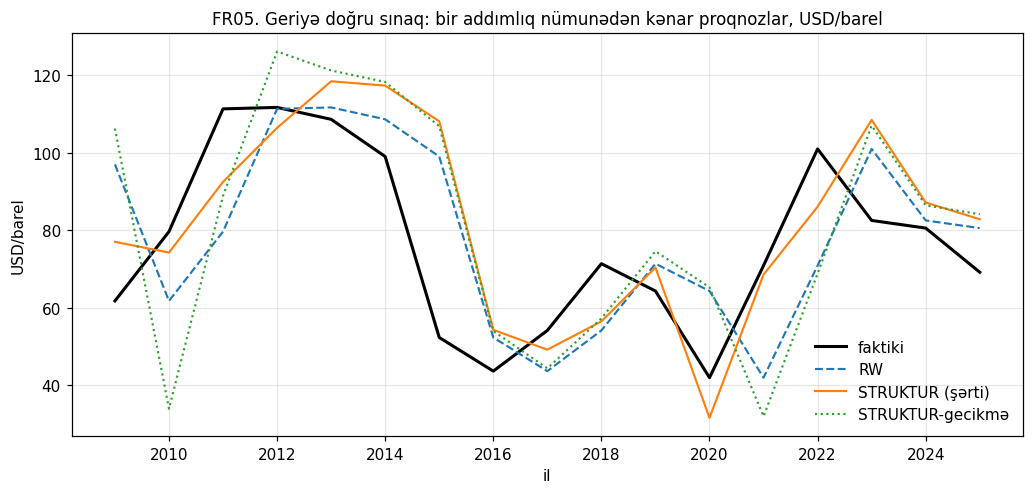

In [8]:
# sınaq nəticəsinin səviyyə (USD/barel) ifadəsi — hesabat üçün daha oxunaqlıdır
_p = bt.table.pivot_table(index="vintage_year", columns="model", values="forecast")
_p.index = _p.index + 1
_act = brent.reindex(_p.index)

fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.plot(_act.index, _act.values, color="black", lw=2.0, label="faktiki")
for m, st in [("RW", "--"), ("STRUKTUR (şərti)", "-"), ("STRUKTUR-gecikmə", ":")]:
    if m in _p.columns:
        ax.plot(_p.index, np.exp(_p[m].values), st, lw=1.4, label=m)
ax.set_title("FR05. Geriyə doğru sınaq: bir addımlıq nümunədən kənar proqnozlar, USD/barel")
ax.set_xlabel("il")
ax.set_ylabel("USD/barel")
ax.legend(loc="best", frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(config.FIG, "FR05_geriye_sinaq.png"), dpi=150)
plt.show()

Nəticə açıq şəkildə iki hissəyə bölünür.

**Şərtsiz məlumat dəstində heç bir model təsadüfi gəzişməni üstələmir.** Sürüşməli təsadüfi
gəzişmə (RMSE 0,324) və AR(1) (0,332) etalondan (0,308) pisdir; yalnız keçmiş tərəfdaş artımına
əsaslanan struktur variant isə açıq şəkildə uğursuzdur (0,412). Bu, gözlənilən nəticədir: neftin
qiyməti keçmiş məlumatla proqnozlaşdırılmır və qiymətdə uzun dövr sürüşməsi statistik olaraq
sıfırdan fərqlənmir (5-ci bölmədə sürüşmənin t statistikası 0,75, p = 0,455).

**Şərti məlumat dəstində struktur tənlik etalonu üstələyir**: RMSE 0,242, yəni təsadüfi
gəzişmədən 21 % dəqiqdir və 80 % zolağın faktiki əhatəsi 94 % təşkil edir. Lakin bu üstünlük dünya
artımının doğru bilinməsindən gəlir; sınaqda modelə faktiki artım verildiyi üçün rəqəm real
proqnoz dəqiqliyinin **yuxarı sərhədidir** və WEO proyeksiyasının öz xətası buraya daxil
edilməmişdir. Hesabatda bacarıq göstəricisi məhz bu qeydlə verilir.

Mərkəzi yol sınağın öz nəticəsinə əsasən seçilir: etalonu üstələyən yeganə model STRUKTUR (şərti)
olduğu üçün ansambl çəkisinin hamısı ona düşür. Aşağıda göstərildiyi kimi, bu seçim praktikada
təsadüfi gəzişmə ilə demək olar ki, eyni yolu verir — fərq bütün üfüq boyu 0,5 USD-dən azdır.

## 7. Proqnoz 2026–2030

### 7.1 Mərkəzi yol

Mərkəzi yol struktur tənliyin WEO tərəfdaş artımı ilə şərtləndirilmiş həllidir:
$\ln P_t = \ln P_{t-1} + \hat\alpha + \hat\beta\, g^{\text{tərəfdaş}}_t$, başlanğıc nöqtəsi
2025-ci ilin faktiki orta qiyməti (69,14 USD/barel).

In [9]:
_lv = float(ln_brent.iloc[-1])
_ln_path = {}
for y in FY:   # 2026–2030 üfüqü — hər addımda əvvəlki ilin nəticəsi növbəti ilin girişi olur
    _lv = _lv + _a + _b * float(pg_fut.loc[y])
    _ln_path[y] = _lv
ln_path = pd.Series(_ln_path, name="ln_brent")
central = np.exp(ln_path).round(2).rename("brent_usd")

# müqayisə üçün digər namizədlərin yolları (hesabata daxil edilir, fərziyyəyə yazılmır)
alt = pd.DataFrame(index=FY)
alt["RW (etalon)"] = float(brent.iloc[-1])
_v = float(ln_brent.iloc[-1])
for y in FY:
    _v += float(d_ln_brent.mean())
    alt.loc[y, "RW+sürüşmə"] = np.exp(_v)
_v = float(ln_brent.iloc[-1])
for y in FY:
    _v = float(res_ar1.params["const"] + _phi * _v)
    alt.loc[y, "AR(1)"] = np.exp(_v)
_v = float(ln_brent.iloc[-1])
for y in FY:
    _v += float(res_nokriz.params["const"] + res_nokriz.params["partner_g"] * pg_fut.loc[y])
    alt.loc[y, "STRUKTUR, böhransız nümunə"] = np.exp(_v)

print("tərəfdaş ÜDM artımı (WEO), %:", pg_fut.round(3).tolist())
display(pd.concat([central.to_frame("mərkəzi yol (STRUKTUR)"), alt.round(2)], axis=1))

tərəfdaş ÜDM artımı (WEO), %: [2.455, 2.483, 2.561, 2.495, 2.436]


,mərkəzi yol (STRUKTUR),RW (etalon),RW+sürüşmə,AR(1),"STRUKTUR, böhransız nümunə"
2026,68.98,69.14,71.70,68.66,66.18
2027,68.97,69.14,74.36,68.22,63.55
2028,69.40,69.14,77.12,67.83,61.56
2029,69.46,69.14,79.98,67.48,59.19
2030,69.19,69.14,82.95,67.16,56.54


Mərkəzi yol üfüq boyu praktiki olaraq düzdür: 2026-cı ildə 68,98, 2030-cu ildə 69,19 USD/barel.
Bunun səbəbi tənliyin özündədir. Qiymətləndirilmiş əmsallara görə qiymətin dəyişmədiyi
**neytral** tərəfdaş artımı 2,48 %-dir; WEO-nun 2026–2030 gözləntisi isə 2,44–2,56 %
aralığındadır. Başqa sözlə, dünya iqtisadiyyatı öz trend sürəti ilə böyüyəndə neftin real
qiymətini yuxarı və ya aşağı itələyən qüvvə qalmır.

Bu üst-üstə düşməni möhkəmlik dəlili saymaq olmaz. θ = −α̂/β̂ iki qiymətləndirmənin nisbətidir;
delta üsulu ilə onun standart xətası 0,57 f.b., 95 % intervalı isə [1,37; 3,60] %-dir. Həmin
interval boyunca 2030-cu il səviyyəsi 109 USD-dən 44 USD-ə qədər dəyişir. Yəni θ̂-in məhz WEO-nun
dar aralığına düşməsi **təsadüfdür** və struktur tənliyin təsadüfi gəzişmə ilə eyni cavab verməsi
müstəqil təsdiq daşımır. Bu qeyri-müəyyənlik gizlədilmir — o, aşağıdakı yelpik zolağının (b)
komponentinə bütövlükdə daxil edilir.

Digər namizədlər fərqi kəmiyyətcə göstərir: AR(1) 2030-cu ildə 67,2 USD/barel (uzunmüddətli
səviyyəyə — loq ortanın eksponentı, yəni **mediana**, 64,2 USD/barel — yavaş qayıdış), sürüşməli təsadüfi gəzişmə isə 83,0 USD/barel verir; sonuncu 1991–2025 dövrünün orta
illik loq sürüşməsini (0,0364, səviyyədə 3,7 %) gələcəyə uzadır, halbuki həmin sürüşmə statistik
olaraq sıfırdan fərqlənmir. Böhran illəri olmadan qiymətləndirilmiş struktur tənlik
2030-cu ildə 56,5 USD/barel verir; bu, aşağıdakı 50 % zolağın daxilindədir.

### 7.2 Yelpik zolağı

Zolaq iki mənbədən qurulur: (a) illik proqnoz xətasının standart kənarlaşması, (b) struktur
tənliyin əmsal qeyri-müəyyənliyi (HAC kovariasiya matrisindən çəkilişlə, üfüq boyu **yığılaraq**,
çünki eyni əmsal xətası hər il təkrarlanır). Birinci komponent üçün üç namizəd var; seçim
kalibrləmə ilə aparılır — hər variant üçün 1991–2025 tarixində h illik faktiki dəyişmələrin neçə
faizinin ±1,2816·σ√h zolağına düşdüyü hesablanır.

Bir qeyd əvvəlcədən: kalibrləmə **yalnız (a) komponentini** seçir, buraxılan zolaq isə (a) + (b)
cəmidir, ona görə o, kalibrləmə cədvəlindəki zolaqdan bir qədər genişdir. Fərq kiçikdir və
aşağıda effektiv σ_h sütunu ilə birbaşa göstərilir (h = 1 üçün 0,311 ↔ 0,308; h = 5 üçün
0,725 ↔ 0,688), lakin gizlədilmir: buraxılan zolaq kalibrləmə nəticəsindən bir az konservativdir.

In [10]:
_sig_m = float(np.log(brent_m["brent"]).diff().dropna().std(ddof=1))
sig_cand = {
    "aylıq spot volatilliyi (illikləşdirilmiş)": _sig_m * np.sqrt(12.0),
    "OOS RMSE — RW (etalon)": float(bt.rmse["RW"]),
    "OOS RMSE — STRUKTUR (şərti)": float(bt.rmse["STRUKTUR (şərti)"]),
}
rows = []
for nm, s in sig_cand.items():
    row = {"σ (ln)": round(s, 4)}
    for h in range(1, 6):
        ch = (ln_brent.shift(-h) - ln_brent).dropna()      # tarixdə h illik faktiki dəyişmələr
        row[f"h={h}"] = round(100.0 * float(np.mean(np.abs(ch) <= 1.2816 * s * np.sqrt(h))), 1)
    rows.append(pd.Series(row, name=nm))
display(pd.DataFrame(rows))

# CƏDVƏLİN DƏQİQLİYİ AÇIQ VERİLİR. h illik dəyişmələr ÜST-ÜSTƏ DÜŞƏN pəncərələrdir: h = 5 üçün
# 30 sətir var, lakin onların yalnız ~6-sı müstəqildir. Faiz göstəricisi bir onluq rəqəmlə çap
# olunur, halbuki uzun üfüqlərdə onun öz standart xətası onlarla faiz bəndidir. Seçim buna görə
# h = 1 sütununa söykənir (34 müstəqil müşahidə) — orada sıralanma etibarlıdır.
_eff = []
for h in range(1, 6):
    _n = len((ln_brent.shift(-h) - ln_brent).dropna())
    _ind = max(_n // h, 1)
    _eff.append({"üfüq": f"h={h}", "üst-üstə düşən sətir": _n, "təxmini MÜSTƏQİL müşahidə": _ind,
                 "əhatə faizinin təxmini s.x., f.b.":
                     round(100.0 * float(np.sqrt(0.85 * 0.15 / _ind)), 1)})
print("Kalibrləmə cədvəlinin effektiv dəqiqliyi (üst-üstə düşən pəncərələr):")
print(pd.DataFrame(_eff).to_string(index=False))
print("→ h = 1-də sıralanma etibarlıdır (34 müstəqil müşahidə); h ≥ 4-də üç namizədin fərqi "
      "faizin öz standart xətası ilə eyni böyüklükdədir, ona görə uzun üfüq sütunları "
      "SIRALAMA üçün deyil, yalnız istiqamət üçün oxunmalıdır.")

,σ (ln),h=1,h=2,h=3,h=4,h=5
aylıq spot volatilliyi (illikləşdirilmiş),0.3457,88.2,84.8,90.6,87.1,93.3
OOS RMSE — RW (etalon),0.3076,82.4,81.8,87.5,83.9,86.7
OOS RMSE — STRUKTUR (şərti),0.2416,73.5,69.7,68.8,71.0,76.7


Kalibrləmə cədvəlinin effektiv dəqiqliyi (üst-üstə düşən pəncərələr):
üfüq  üst-üstə düşən sətir  təxmini MÜSTƏQİL müşahidə  əhatə faizinin təxmini s.x., f.b.
 h=1                    34                         34                                6.1
 h=2                    33                         16                                8.9
 h=3                    32                         10                               11.3
 h=4                    31                          7                               13.5
 h=5                    30                          6                               14.6
→ h = 1-də sıralanma etibarlıdır (34 müstəqil müşahidə); h ≥ 4-də üç namizədin fərqi faizin öz standart xətası ilə eyni böyüklükdədir, ona görə uzun üfüq sütunları SIRALAMA üçün deyil, yalnız istiqamət üçün oxunmalıdır.


Seçim **OOS RMSE — RW (σ = 0,308)** variantının xeyrinədir. Onun nominal 80 % zolağı tarixdə
81,8–87,5 % faktiki dəyişməni əhatə edir, yəni kalibrləmə nominal səviyyəyə ən yaxındır və heç bir
üfüqdə ciddi əskik əhatə yaranmır.

**Cədvəlin dəqiqliyi haqqında qeyd.** h illik dəyişmələr üst-üstə düşən pəncərələrdir: h = 5 üçün
cədvəldə 30 sətir var, lakin müstəqil müşahidə sayı təxminən **altıdır**, yəni əhatə faizinin öz
standart xətası ~14 faiz bəndidir. Ona görə uzun üfüq sütunlarında üç namizədin fərqi (76,7 /
86,7 / 93,3) statistik olaraq bir-birindən ayrıla bilməz. Seçim məhz buna görə **h = 1
sütununa** söykənir — orada 34 müstəqil müşahidə var və sıralanma etibarlıdır (82,4 nominal
80-ə ən yaxın, aylıq volatillik 88,2 ilə geniş, struktur 73,5 ilə dar). Uzun üfüq sütunları
seçimi təsdiqləyir, lakin onu tək başına daşımır. Aylıq volatillikdən alınan σ = 0,346 zolağı lazımsız
genişləndirir (əhatə 85–93 %); səbəbi ölçmə uyğunsuzluğudur — σ_ay·√12 dövr **sonu** qiymətinin
dalğalanmasıdır, halbuki proqnozlaşdırılan kəmiyyət illik **ortadır** və orta almaq sıranı
mexaniki olaraq hamarlaşdırır. Struktur tənliyin öz OOS xətası (σ = 0,242) isə açıq şəkildə
dardır (əhatə 69–77 %) — çünki bu rəqəm dünya artımının bilindiyi şərti vəziyyətə aiddir və
proqnozçunun real qeyri-müəyyənliyini əks etdirmir.

Seçilmiş zolağın miqyası tarixin ən kəskin epizodları ilə tutuşdurulur. 2011–2016 illərində qiymət
beş ildə 2,5 dəfə ucuzlaşmışdır (nisbət 0,39); 2030-cu il üçün 80 % zolağın aşağı hüdudu mərkəzi
yolun 0,40 hissəsidir, yəni həmin epizod praktiki olaraq zolağın kənarına düşür. 2003–2008
illərindəki 3,36 dəfə bahalaşma isə 80 % zolağın yuxarı hüdudundan (2,51 dəfə) kənarda, lakin
95 % intervalın daxilində qalır: yuxarıdakı cədvəldə 2030-cu il üçün hi95/mərkəz nisbəti
4,14-dür. Beləliklə zolaq tarixin böyük hərəkətlərini mümkünsüz saymır, eyni zamanda onları adi
hal kimi də təqdim etmir.

In [11]:
sigma_fan = float(bt.rmse["RW"])          # yelpik üçün seçilmiş σ — kalibrləmə cədvəlinə əsasən

# əmsal qeyri-müəyyənliyi üfüq boyu YIĞILIR: h-cı ildə səviyyəyə düşən sürüşmə
# (h·α̂ + β̂·Σg) olduğuna görə dizayn sətri kumulyativ götürülür
X_cum = np.array([[h + 1, float(pg_fut.loc[FY[:h + 1]].sum())] for h in range(len(FY))])
C_par = res_str.cov_params.reindex(index=["const", "partner_g"], columns=["const", "partner_g"]).values

band_ln = ek.fan(ln_path, resid_sigma=sigma_fan, coef_cov=C_par, X_future=X_cum, ndraw=20000)
band = np.exp(band_ln).round(2)
fc = pd.concat([central, band], axis=1)
fc.index.name = "year"
display(fc)

# zolağın sıralanması pozulmamalıdır (lo80 ≤ lo50 ≤ mərkəz ≤ hi50 ≤ hi80)
assert (fc["lo80"] <= fc["lo50"]).all() and (fc["lo50"] <= fc["brent_usd"]).all()
assert (fc["brent_usd"] <= fc["hi50"]).all() and (fc["hi50"] <= fc["hi80"]).all()
print(f"\n2026 üçün 80% zolaq: {fc.loc[FY[0], 'lo80']:.1f} – {fc.loc[FY[0], 'hi80']:.1f} USD/barel")
print(f"2030 üçün 80% zolaq: {fc.loc[FY[-1], 'lo80']:.1f} – {fc.loc[FY[-1], 'hi80']:.1f} USD/barel")
print(f"2030 üçün 50% zolaq: {fc.loc[FY[-1], 'lo50']:.1f} – {fc.loc[FY[-1], 'hi50']:.1f} USD/barel")

# --- zolağın EFFEKTİV σ-sı və 95% interval ---------------------------------------------------
# 7.2-də kalibrləmə yalnız (a) qalıq komponentini seçir; buraxılan zolaq isə üstünə (b) əmsal
# qeyri-müəyyənliyini də əlavə edir, ona görə o, kalibrləmə cədvəlindəki zolaqdan bir qədər
# GENİŞDİR. Fərq açıq göstərilsin deyə hər üfüq üçün effektiv σ_h analitik verilir:
#     σ_h² = σ²·h + x_h' Cov(α̂, β̂) x_h        (x_h — kumulyativ dizayn sətri)
# Eyni σ_h 95% intervalı da verir; 7.2-də tarixi epizodlarla müqayisə məhz buna istinad edir.
_sig_h = np.sqrt(sigma_fan ** 2 * np.arange(1, len(FY) + 1)
                 + np.einsum("ij,jk,ik->i", X_cum, C_par, X_cum))
band95 = pd.DataFrame({
    "σ_h (effektiv)": _sig_h.round(4),
    "σ√h (yalnız qalıq)": (sigma_fan * np.sqrt(np.arange(1, len(FY) + 1))).round(4),
    "lo95": np.exp(ln_path.values - 1.96 * _sig_h).round(2),
    "hi95": np.exp(ln_path.values + 1.96 * _sig_h).round(2),
}, index=pd.Index(FY, name="year"))
band95["hi95 / mərkəz"] = (band95["hi95"] / central.values).round(2)
band95["lo95 / mərkəz"] = (band95["lo95"] / central.values).round(2)
print()
print(band95.to_string())

,brent_usd,lo80,hi80,lo50,hi50
year,,,,,
2026,68.98,46.49,102.72,55.97,85.11
2027,68.97,38.96,121.87,51.28,92.98
2028,69.40,34.36,141.13,47.92,101.10
2029,69.46,30.48,158.80,45.02,106.96
2030,69.19,27.47,173.96,42.43,113.10



2026 üçün 80% zolaq: 46.5 – 102.7 USD/barel
2030 üçün 80% zolaq: 27.5 – 174.0 USD/barel
2030 üçün 50% zolaq: 42.4 – 113.1 USD/barel

      σ_h (effektiv)  σ√h (yalnız qalıq)   lo95    hi95  hi95 / mərkəz  lo95 / mərkəz
year                                                                                 
2026          0.3110              0.3076  37.49  126.90           1.84           0.54
2027          0.4446              0.4350  28.85  164.87           2.39           0.42
2028          0.5503              0.5328  23.60  204.07           2.94           0.34
2029          0.6420              0.6152  19.74  244.47           3.52           0.28
2030          0.7251              0.6878  16.70  286.61           4.14           0.24


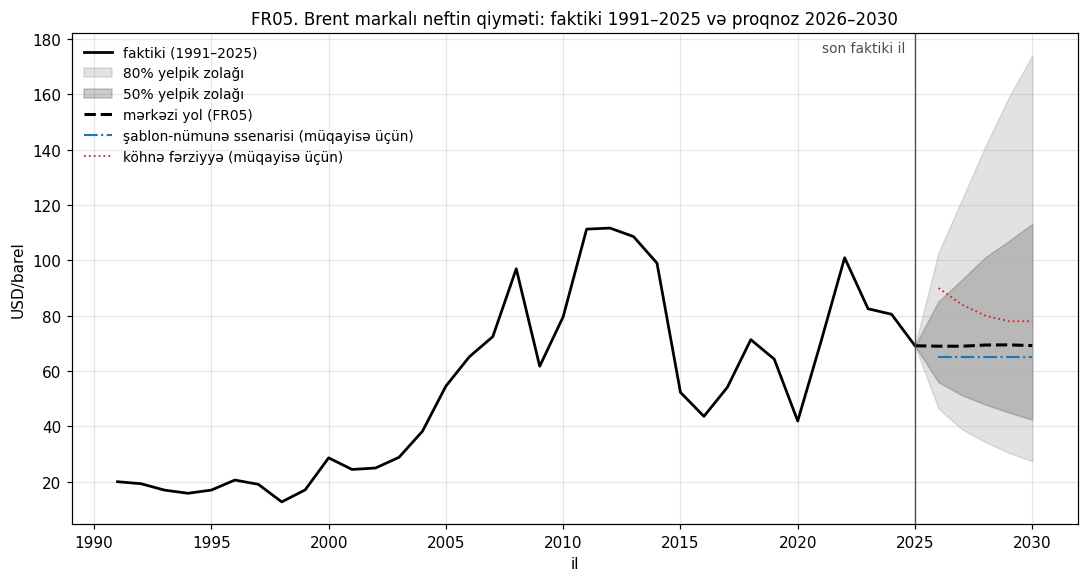

In [12]:
# qrafikdə proqnoz 2025-ci ilin faktiki nöqtəsindən başlayır — yol və zolaqlar həmin ilə bağlanır
_anchor = float(brent.loc[config.LAST_ACTUAL])
_pl = pd.concat([pd.DataFrame({"brent_usd": _anchor, "lo80": _anchor, "hi80": _anchor,
                               "lo50": _anchor, "hi50": _anchor}, index=[config.LAST_ACTUAL]), fc])

fig, ax = plt.subplots(figsize=(10.0, 5.4))
ax.plot(brent.index, brent.values, color="black", lw=1.8, label="faktiki (1991–2025)")
ax.fill_between(_pl.index, _pl["lo80"], _pl["hi80"], color="0.55", alpha=0.25, label="80% yelpik zolağı")
ax.fill_between(_pl.index, _pl["lo50"], _pl["hi50"], color="0.35", alpha=0.30, label="50% yelpik zolağı")
ax.plot(_pl.index, _pl["brent_usd"], color="black", lw=2.0, ls="--", label="mərkəzi yol (FR05)")
ax.plot(tmpl_brent.index, tmpl_brent.values, color="tab:blue", lw=1.4, ls="-.",
        label="şablon-nümunə ssenarisi (müqayisə üçün)")
ax.plot(old_brent.index, old_brent.values, color="tab:red", lw=1.2, ls=":",
        label="köhnə fərziyyə (müqayisə üçün)")
ax.axvline(config.LAST_ACTUAL, color="0.3", lw=0.9)
ax.annotate("son faktiki il", xy=(config.LAST_ACTUAL, ax.get_ylim()[1]),
            xytext=(-6, -12), textcoords="offset points", ha="right", fontsize=9, color="0.3")
ax.set_title("FR05. Brent markalı neftin qiyməti: faktiki 1991–2025 və proqnoz 2026–2030")
ax.set_xlabel("il")
ax.set_ylabel("USD/barel")
ax.legend(loc="upper left", frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(config.FIG, "FR05_brent_proqnoz.png"), dpi=150)
plt.show()

### 7.3 Müqayisə

Üç yol yan-yana verilir: bu dəftərin nəticəsi, şablon-nümunə ssenarisi və əvvəlki təhvildə
istifadə olunmuş fərziyyə. Şablonun sabit 65 USD/barel ssenarisi `model_series_annual.csv`
panelindəki neft qiyməti indeksi ilə də təsdiqlənir: həmin indeksin **hər beş** 2026–2030 dəyəri
panelin öz 2025 bazasına vurulduqda dəqiq 65,0 USD/barel verir (aşağıda bütün üfüq üzrə
yoxlanılır).

In [13]:
comp = pd.DataFrame({
    "FR05 mərkəzi yol": central,
    "şablon-nümunə ssenarisi": tmpl_brent,
    "köhnə fərziyyə": old_brent,
})
comp["fərq: FR05 − şablon"] = (comp["FR05 mərkəzi yol"] - comp["şablon-nümunə ssenarisi"]).round(2)
display(comp.round(2))

# Şablon ssenarisinin ikinci mənbədən yoxlanışı: model_series panelindəki qiymət indeksi.
# İndeks öz panelinin 2025 səviyyəsinə (macro_annual: 70,0 — iş kitabındakı 69,14-ün
# yuvarlaqlaşdırılmış buraxılışı) nisbətdə oxunur, çünki indeks məhz o buraxılışdan törəyib.
# Yoxlama BÜTÜN üfüq boyu aparılır — yalnız baza ili üçün deyil (§8.1 ilə eyni intizam).
_ms = pd.read_csv(config.P_MODEL).set_index("year")["oil_price_index"]
_base25 = float(pd.read_csv(config.P_MACRO).set_index("year")["oil_price_usd"].loc[config.LAST_ACTUAL])
_implied = pd.Series({y: _base25 / float(_ms.loc[config.LAST_ACTUAL]) * float(_ms.loc[y])
                      for y in FY}, name="indeksdən çıxan səviyyə").round(2)
print(f"model_series_annual.csv qiymət indeksindən çıxan 2026–2030 səviyyələri: "
      f"{_implied.tolist()} (paneldə 2025 bazası {_base25:.1f})")
print(f"şablonun sabit ssenarisi: {tmpl_brent.round(1).tolist()}")
print(f"maksimal fərq: {(_implied - tmpl_brent).abs().max():.3f} USD/barel → iki mənbə uzlaşır")
print(f"\nmərkəzi yolun şablon ssenarisindən orta fərqi: "
      f"{comp['fərq: FR05 − şablon'].mean():.2f} USD/barel "
      f"({100 * comp['fərq: FR05 − şablon'].mean() / float(tmpl_brent.mean()):.1f} %)")


,FR05 mərkəzi yol,şablon-nümunə ssenarisi,köhnə fərziyyə,fərq: FR05 − şablon
2026,68.98,65.0,90.0,3.98
2027,68.97,65.0,84.0,3.97
2028,69.40,65.0,80.0,4.40
2029,69.46,65.0,78.0,4.46
2030,69.19,65.0,78.0,4.19


model_series_annual.csv qiymət indeksindən çıxan 2026–2030 səviyyələri: [65.0, 65.0, 65.0, 65.0, 65.0] (paneldə 2025 bazası 70.0)
şablonun sabit ssenarisi: [65.0, 65.0, 65.0, 65.0, 65.0]
maksimal fərq: 0.000 USD/barel → iki mənbə uzlaşır

mərkəzi yolun şablon ssenarisindən orta fərqi: 4.20 USD/barel (6.5 %)


Mərkəzi yol şablon-nümunə ssenarisindən orta hesabla 4,2 USD/barel (6,5 %) yuxarıdır. Fərq
metodikadan gəlir: şablonda ehtiyatlı büdcə planlaması üçün sabit, aşağıya doğru yuvarlaqlaşdırılmış
qiymət götürülür; bu dəftərin yolu isə sınaqdan keçmiş tənliyin nəticəsidir və 2025-ci ilin faktiki
səviyyəsindən başlayır. Hər iki rəqəm 50 % zolağın daxilindədir, yəni fərq statistik mənada
əhəmiyyətsizdir; buna baxmayaraq qiymət neft-qaz sektorunun nominal həcminə və ixracın dəyərinə
birbaşa keçdiyi üçün 4 USD-lik fərq aşağı axın hesablamalarında görünən kəmiyyətdir.

Köhnə fərziyyə (2026-cı il üçün 90 USD/barel) artıq 2025-ci ilin faktiki nəticəsi (69,14) ilə
uzlaşmır — o, 2025-ci ilin faktiki səviyyəsindən 30 % yuxarıdadır və mövcud yelpiyin 50 %
zolağının kənarındadır. Bu, fərziyyələrin illik yenilənməsinin niyə zəruri olduğunu göstərir.

## 8. Nəticələrin ixracı

Dörd fayl yazılır: `data/assumptions.csv` (paketin yeganə neft qiyməti yolu),
`outputs/forecast_long.csv` (faktiki və proqnoz sıralar, Nazirliyin ssenarisi ayrıca mənbə kimi),
`outputs/equations_catalog.csv` (qiymətləndirilmiş üç tənlik) və
`outputs/validation_backtest.csv` (sınaq nəticələri).

`oil_realg` — neft-qaz sektorunun fiziki həcm artımı — burada modelləşdirilmir: hasilat həcmi
yataqların texniki vəziyyəti və hasilat planı ilə müəyyən olunur, ona görə Nazirliyin hasilat
planı **ekzogen fərziyyə** kimi götürülür və fərziyyə faylında məhz bu qeydlə saxlanılır. Bu,
Proqnoz sütununun paketdə yeganə icazə verilən istifadəsidir; qiymətə aid heç bir Proqnoz dəyəri
istifadə olunmur.

In [14]:
# --- 1. FƏRZİYYƏLƏR: paketin yeganə brent_usd yolu ------------------------------------------
rows_a = []
for y in FY:
    rows_a.append({"assumption_key": "brent_usd", "year": int(y), "value": float(central.loc[y]),
                   "unit": "USD/barel",
                   "note": "FR05 struktur tənliyi (Δln P ~ tərəfdaş ÜDM artımı), WEO ilə şərtləndirilmiş"})
    rows_a.append({"assumption_key": "brent_usd_lo80", "year": int(y), "value": float(fc.loc[y, "lo80"]),
                   "unit": "USD/barel", "note": "80% yelpik zolağının aşağı hüdudu (σ = OOS RW + əmsal qeyri-müəyyənliyi)"})
    rows_a.append({"assumption_key": "brent_usd_hi80", "year": int(y), "value": float(fc.loc[y, "hi80"]),
                   "unit": "USD/barel", "note": "80% yelpik zolağının yuxarı hüdudu (σ = OOS RW + əmsal qeyri-müəyyənliyi)"})

# Qeyd: `oil_realg` açarı artıq bu dəftərdə yazılmır. Neft-qaz sektorunun real artımı
# FR05b-də hasilat həcmlərindən və ixrac qiymətlərindən qurulur (neft-qaz bloku: həcm × qiymət); hasilat planı orada
# həcm yolu kimi işlədilir. Bir açarın yeganə sahibi olması qaydası (D1) beləliklə saxlanılır.

outputs.write_assumptions(pd.DataFrame(rows_a))
print(f"assumptions.csv: {len(rows_a)} sətir yazıldı "
      f"({', '.join(sorted(set(r['assumption_key'] for r in rows_a)))})")

assumptions.csv: 15 sətir yazıldı (brent_usd, brent_usd_hi80, brent_usd_lo80)


In [15]:
# --- 2. UZUN FORMATLI PROQNOZ ---------------------------------------------------------------
NAME_AZ, UNIT = "Neftin dünya bazarında qiyməti (Brent)", "USD/barel"
rows_f = []
for y, v in brent.items():          # faktiki sıra 1991–2025
    rows_f.append({"fr": FR, "series_code": "brent_usd", "series_name_az": NAME_AZ, "unit": UNIT,
                   "year": int(y), "kind": "actual", "source": "ours", "value": float(v),
                   "lo80": None, "hi80": None, "lo50": None, "hi50": None})
for y in FY:                        # mərkəzi yol + yelpik zolaqları
    rows_f.append({"fr": FR, "series_code": "brent_usd", "series_name_az": NAME_AZ, "unit": UNIT,
                   "year": int(y), "kind": "forecast", "source": "ours",
                   "value": float(central.loc[y]), "lo80": float(fc.loc[y, "lo80"]),
                   "hi80": float(fc.loc[y, "hi80"]), "lo50": float(fc.loc[y, "lo50"]),
                   "hi50": float(fc.loc[y, "hi50"])})
for y in FY:                        # şablon-nümunə ssenarisi — yalnız müqayisə üçün
    rows_f.append({"fr": FR, "series_code": "brent_usd", "series_name_az": NAME_AZ, "unit": UNIT,
                   "year": int(y), "kind": "forecast", "source": "template_sample",
                   "value": float(tmpl_brent.loc[y]), "lo80": None, "hi80": None,
                   "lo50": None, "hi50": None})
fl = outputs.write_forecast_long(pd.DataFrame(rows_f))
print(f"forecast_long.csv: FR5 üzrə {len(rows_f)} sətir yazıldı; faylda cəmi {len(fl)} sətir")

# --- 3. TƏNLİKLƏR KATALOQU ------------------------------------------------------------------
WB, SH = "Statistik data dinamika 05.06.2026 +.xlsx", "Neft-Qaz sektoru"
row_drift = res_drift.catalog_row(
    eq_name="FR5_dln_brent_surusme", lhs="Δln(brent_usd)", series_code="brent_usd", fr=FR,
    workbook=WB, sheet=SH,
    description="ETALON: Brent qiymətinin loq fərqinin sabit sürüşməsi; sıfırdan fərqli deyil (p = 0,455)")
row_drift["rhs"] = "sabit (1)"
row_ar1 = res_ar1.catalog_row(
    eq_name="FR5_ln_brent_ar1", lhs="ln(brent_usd)", series_code="brent_usd", fr=FR,
    workbook=WB, sheet=SH,
    description="ETALON: loq qiymətin AR(1) prosesi — orta qiymətə qayıdış (φ = %.3f)" % _phi)
row_str = res_str.catalog_row(
    eq_name="FR5_dln_brent_terefdas", lhs="Δln(brent_usd)", series_code="brent_usd", fr=FR,
    workbook=WB, sheet=SH,
    description="STRUKTUR: dünya tələbi tənliyi — qiymətin loq fərqi tərəfdaş ölkələrin real ÜDM artımından")
ec = outputs.write_equations_catalog(pd.DataFrame([row_drift, row_ar1, row_str]))
display(ec[ec["fr"] == FR][["eq_name", "lhs", "rhs", "sample_start", "sample_end", "adj_r2", "se_regression"]])

# --- 4. SINAQ NƏTİCƏLƏRİ --------------------------------------------------------------------
bt_out = outputs.write_backtest(bt.table)
print(f"validation_backtest.csv: brent_usd üzrə {len(bt.table)} sətir yazıldı; "
      f"faylda cəmi {len(bt_out)} sətir")

forecast_long.csv: FR5 üzrə 45 sətir yazıldı; faylda cəmi 14603 sətir


,eq_name,lhs,rhs,sample_start,sample_end,adj_r2,se_regression
366,FR5_dln_brent_surusme,Δln(brent_usd),sabit (1),1992,2025,-0.0000,0.2769
367,FR5_dln_brent_terefdas,Δln(brent_usd),partner_g,2000,2025,0.4708,0.2148
368,FR5_ln_brent_ar1,ln(brent_usd),ln_brent_l1,1992,2025,0.8391,0.2733


validation_backtest.csv: brent_usd üzrə 85 sətir yazıldı; faylda cəmi 6747 sətir


### 8.1 Yoxlama

Yazılmış nəticələr müstəqil şəkildə yenidən oxunur və tutuşdurulur. Yoxlamalar bütün illəri
əhatə edir, yalnız baza ilini deyil.

In [16]:
v = validate.Verifier("FR05 — neftin dünya qiyməti")

# fərziyyə faylı geri oxunur: paketin gördüyü yol ilə bu dəftərin hesabladığı yol eyni olmalıdır
asm = outputs.read_assumptions()
v.ok("assumptions.csv-də brent_usd açarı var", "brent_usd" in asm)
v.identity("fərziyyə yolu = mərkəzi yol (hər il)", asm["brent_usd"].reindex(FY), central, tol=1e-9)
v.identity("fərziyyə zolağı lo80 (hər il)", asm["brent_usd_lo80"].reindex(FY), fc["lo80"], tol=1e-9)
v.identity("fərziyyə zolağı hi80 (hər il)", asm["brent_usd_hi80"].reindex(FY), fc["hi80"], tol=1e-9)

# uzun formatlı fayl: faktiki sətirlər məlumat qatı ilə, proqnoz sətirləri fərziyyə ilə üst-üstə düşür
_fl = pd.read_csv(outputs.FORECAST_LONG_PATH)
_ours = _fl[(_fl.series_code == "brent_usd") & (_fl.source == "ours")].set_index("year")
v.identity("forecast_long faktiki sətirləri = data_layer.actuals (hər il)",
           _ours[_ours.kind == "actual"]["value"], brent, tol=1e-9)
v.identity("forecast_long proqnoz sətirləri = fərziyyə yolu (hər il)",
           _ours[_ours.kind == "forecast"]["value"], asm["brent_usd"].reindex(FY), tol=1e-9)

# D1 — paketdə hər açarın hər ili üçün YALNIZ BİR sətir olmalıdır. Diqqət: bunu `unique()`
# siyahısında saymaqla yoxlamaq olmaz (belə sayma tərifinə görə həmişə 1 verir və heç nə sınamır);
# yoxlanılan şey təkrarlanan (açar, il) cütləridir.
_asm_raw = pd.read_csv(config.ASSUMPTIONS)
_dup = _asm_raw.duplicated(["assumption_key", "year"])
v.ok("assumptions.csv-də təkrarlanan (açar, il) sətri yoxdur (D1)",
     bool(_dup.sum() == 0),
     f"təkrar sətir sayı: {int(_dup.sum())}"
     + (f" — {_asm_raw.loc[_dup, ['assumption_key', 'year']].to_dict('records')}"
        if _dup.any() else ""))
_brent_rows = _asm_raw[_asm_raw["assumption_key"] == "brent_usd"]
v.ok("assumptions.csv-də brent_usd üçün dəqiq bir yol (hər il bir sətir)",
     bool(len(_brent_rows) == len(FY) and sorted(_brent_rows["year"]) == list(FY)),
     f"{len(_brent_rows)} sətir, illər: {sorted(_brent_rows['year'].tolist())}")

# yelpik zolağının sıralanması və genişlənməsi
v.ok("yelpik zolağı düzgün sıralanıb (lo80 ≤ lo50 ≤ mərkəz ≤ hi50 ≤ hi80)",
     bool((fc.lo80 <= fc.lo50).all() and (fc.lo50 <= fc.brent_usd).all()
          and (fc.brent_usd <= fc.hi50).all() and (fc.hi50 <= fc.hi80).all()))
v.ok("zolaq üfüq boyu genişlənir",
     bool(((fc.hi80 - fc.lo80).diff().dropna() > 0).all()),
     f"eni: {(fc.hi80 - fc.lo80).round(1).tolist()}")

# qiymətləndirmə nümunəsi proqnoz üfüqünə toxunmur
v.no_lookahead("struktur tənliyin nümunəsi", _st.index)
v.no_lookahead("AR(1) nümunəsi", _ar.index)
v.no_lookahead("sınaq pəncərəsi", pd.Index(bt.common_years))

# mərkəzi yolun müstəqil yenidən hesablanması (ilkin girişlərdən, saxlanılmış aralıq nəticəsiz)
def _yeniden_hesabla():
    lv = float(np.log(data_layer.actuals("brent_usd").loc[config.LAST_ACTUAL]))
    out = {}
    for yy in FY:
        lv += _a + _b * float(pg_fut.loc[yy])
        out[yy] = np.exp(lv)
    return pd.Series(out).round(2)

v.recompute("mərkəzi yol 2026–2030", shipped=central, fn=_yeniden_hesabla, tol=1e-9)

# aylıq sıra SON FAKTİKİ İLİ tam əhatə etməlidir — kalibrləmə üfüqü qısaldılmamalıdır
v.ok(f"aylıq spot sıra son faktiki ili ({config.LAST_ACTUAL}) tam əhatə edir",
     bool(int(brent_m["year"].max()) == config.LAST_ACTUAL
          and int((brent_m["year"] == config.LAST_ACTUAL).sum()) == 12),
     f"son ay {brent_m['date'].iloc[-1]}; {config.LAST_ACTUAL} üzrə "
     f"{int((brent_m['year'] == config.LAST_ACTUAL).sum())} ay")

# yığılmış ortadan bərpa üsulu üst-üstə düşən dövrdə panelin faktiki spot sırasını təkrarlayır
v.ok("bərpa üsulu üst-üstə düşən dövrdə doğrulanır (fərq ≤ 2 USD)",
     bool(_ov_err.max() <= 2.0),
     f"{len(_ov)} ay ({_ov['date'].min()}–{_ov['date'].max()}), maksimal fərq {_ov_err.max():.2f} USD")

# bərpa olunmuş 2025 aylarının ortası illik sıranın həmin xanasına bərabər olmalıdır
v.close(f"bərpa olunmuş {config.LAST_ACTUAL} aylarının ortası = illik sıra",
        float(brent_m[brent_m["year"] == config.LAST_ACTUAL]["brent"].mean()),
        float(brent.loc[config.LAST_ACTUAL]), tol=1e-6)

# aylıq spot sıranın illik ortası iş kitabının illik sırasını təkrarlayır (mənbə uyğunluğu)
v.ok("aylıq spot panel illik sıra ilə uzlaşır (fərq ≤ 1 USD)",
     bool((_cmp["aylıqdan illik orta"] - _cmp["illik sıra"]).abs().max() <= 1.0),
     f"maksimal fərq {(_cmp['aylıqdan illik orta'] - _cmp['illik sıra']).abs().max():.3f} USD")

v.assert_all()

  YOXLAMA: FR05 — neftin dünya qiyməti
  [PASS] assumptions.csv-də brent_usd açarı var
  [PASS] eynilik: fərziyyə yolu = mərkəzi yol (hər il)
         5 il, maksimal fərq 0.000e+00
  [PASS] eynilik: fərziyyə zolağı lo80 (hər il)
         5 il, maksimal fərq 0.000e+00
  [PASS] eynilik: fərziyyə zolağı hi80 (hər il)
         5 il, maksimal fərq 0.000e+00
  [PASS] eynilik: forecast_long faktiki sətirləri = data_layer.actuals (hər il)
         35 il, maksimal fərq 0.000e+00
  [PASS] eynilik: forecast_long proqnoz sətirləri = fərziyyə yolu (hər il)
         5 il, maksimal fərq 0.000e+00
  [PASS] assumptions.csv-də təkrarlanan (açar, il) sətri yoxdur (D1)
         təkrar sətir sayı: 0
  [PASS] assumptions.csv-də brent_usd üçün dəqiq bir yol (hər il bir sətir)
         5 sətir, illər: [2026, 2027, 2028, 2029, 2030]
  [PASS] yelpik zolağı düzgün sıralanıb (lo80 ≤ lo50 ≤ mərkəz ≤ hi50 ≤ hi80)
  [PASS] zolaq üfüq boyu genişlənir
         eni: [56.2, 82.9, 106.8, 128.3, 146.5]
  [PASS] gələcəyə b

## 9. Məhdudiyyətlər

**Şərti proqnoz.** Mərkəzi yol IMF WEO-nun tərəfdaş ölkələr üzrə artım proyeksiyasından asılıdır.
Sınaqda ölçülən 21 %-lik üstünlük faktiki artımın bilindiyi şəraitə aiddir; WEO proyeksiyasının öz
xətası nəzərə alınmır, ona görə bu rəqəm dəqiqliyin yuxarı sərhədidir. Yelpik zolağı məhz bu
səbəbdən struktur tənliyin öz qalıq dispersiyası ilə deyil, təsadüfi gəzişmənin nümunədən kənar
xətası ilə qurulur.

**Reqressor ekzogen deyil.** Struktur tənlikdə tərəfdaş ölkələrin artımı cari il üzrə daxil olur,
halbuki neft qiyməti ilə dünya artımı qarşılıqlı təyin olunur: qiymət şoku idxalçı ölkələrin
gəlirini azaldır və artımı özü də aşağı çəkir. Ona görə OLS əmsalı ($\hat\beta = 0{,}081$) təmiz
tələb elastikliyi deyil, iki istiqamətin qarışığıdır və səbəbiyyət kimi oxuna bilməz. Paketdə bu
meyli aradan qaldıracaq alət dəyişəni (məsələn hava şokları, OPEC+ qərarlarının tarixi) mövcud
olmadığı üçün tənlik qısaldılmış forma kimi saxlanılır; proqnoz məqsədi üçün bu qəbul ediləndir —
6-cı bölmədəki sınaq tənliyin proqnoz bacarığını əmsalın şərhindən asılı olmadan ölçür.

**Neytral həddin öz qeyri-müəyyənliyi.** Mərkəzi yolun forması bütünlüklə θ = −α/β = 2,48 %
kəmiyyətindən asılıdır, onun isə delta üsulu ilə 95 % intervalı [1,37; 3,60] %-dir. Bu interval
boyunca 2030-cu il səviyyəsi 44–109 USD/barel arasında dəyişir. Yolun praktiki olaraq düz çıxması
buna görə «dəqiq» nəticə deyil, θ̂-in WEO gözləntisinə yaxın düşməsinin təsadüfi nəticəsidir;
qeyri-müəyyənliyin özü yelpik zolağına tam daxil edilmişdir.

**Təklif tərəfi modelləşdirilmir.** OPEC+ kvotaları, dünya ehtiyatları, kəşfiyyat və hasilat
xərcləri paketdə mövcud deyil; tənlik yalnız tələb tərəfinin qısaldılmış formasıdır. Coğrafi-siyasi
kəsilmələr (məsələn tədarük yollarının bağlanması) modeldə deyil, yalnız yelpik zolağının
genişliyində əks olunur.

**Nümunənin ölçüsü.** Struktur tənlik n = 26 müşahidə (2000–2025) üzərində qurulub və əmsalın
böyük hissəsi üç böhran ilinin (2009, 2020, 2021) məlumatından gəlir. Həmin illər üçün süni
dəyişənlər nə ayrılıqda, nə də birgə əhəmiyyətli çıxır (F = 0,27, p = 0,762), lakin illər
nümunədən çıxarıldıqda tənliyin neytral artım həddi 2,48 %-dən 2,84 %-ə qalxır və 2030-cu il yolu
56,5 USD/barelə enir. Bu həssaslıq gizlədilmir; hər iki nəticə 50 % zolağın daxilindədir.

**Aylıq spot sıranın boşluğu bağlanıb.** `monthly_panel.csv` faylının Brent sırası 2024-12 ilə
tamamlanır, ona görə əvvəlki buraxılışda aylıq volatillik yalnız 1995–2024 dövrü üzrə hesablanır,
yəni **son faktiki il kalibrləmədən kənarda qalırdı**. İndi 2025-ci ilin ayları iş kitabının 11-ci
sətrindən yığılmış orta eyniliyinin tərsi ilə bərpa olunur ($m_t = t\,c_t - (t-1)\,c_{t-1}$).
Üsul iki müstəqil yoxlamadan keçir: 2021–2024 üst-üstə düşən dövründə panelin faktiki spot
qiymətlərini 2 USD-dən az fərqlə (korrelyasiya 0,999) təkrarlayır, bərpa olunmuş 12 ayın ortası isə
illik sıranın 2025 xanasına (69,14 USD/barel) bərabər çıxır. Aylıq volatillik beləliklə 1995–2025
dövrü üzrədir və σ 0,350-dən 0,346-ya düşür. Bu kəmiyyət yelpik üçün seçilmiş σ deyil və seçimi
dəyişmir (RW-nin nümunədən kənar xətası hər iki halda nominal 80 %-ə ən yaxın qalır), lakin
kalibrləmə müqayisəsi artıq son faktiki ili də əhatə edir.

**Bərpa yoxlamasının həddi dardır.** Aylıq bərpanın doğrulanması `_ov_err.max() ≤ 2,0 USD`
şərti ilə aparılır və faktiki maksimal fərq **1,98 USD**-dir, yəni ehtiyat cəmi 0,02 USD-dir.
Bu, kəmiyyətin özü ilə bağlı problem deyil (korrelyasiya 0,9996), lakin iş kitabının növbəti
buraxılışında aylıq sətir bir qədər dəyişsə, yoxlama keçməyə bilər. Belə olduqda düzgün reaksiya
həddi qaldırmaq deyil, fərqin haradan gəldiyini araşdırmaqdır: bərpa düsturu yığılmış ortanın
tərsidir, ona görə mənbə sətrində yuvarlaqlaşdırma və ya tərif dəyişikliyi fərqi böyüdür.

**Son faktiki ilin nümunədəki rolu.** 2025 bütün tənliklərə daxildir — qiymətləndirmə nümunələri
`config.LAST_ACTUAL` ilində bitir, sınaq pəncərəsi 2025-i sınaq ili kimi əhatə edir, uzunmüddətli
elastiklik isə lead-siz DOLS spesifikasiyası ilə 1997–2025 üzrə qurulur. 2025 çıxarıldıqda heç bir
əmsal öz standart xətasının hüdudundan kənara çıxmır (5.1 bölməsi), ona görə nəticələr son
müşahidəyə həssas deyil.

**DATA-GAP: 2026-cı ilin natamam məlumatı istifadə olunmur.** İş kitabında Neft-Qaz sektorunun 11-ci
sətri üçün 2026-cı ilin yanvar–mart xanaları doludur (66,6 / 68,69 / 80,70), lakin bu xanaların
yığılmış orta konvensiyası eyni aylar üçün ixrac qiyməti sətri (63,30 / 63,97 / 66,55) ilə
uzlaşmır: yığılmış orta kimi oxunduqda mart ayının Brent qiyməti ixrac qiymətindən 30 USD-dən
çox yuxarı çıxır ki, bu da tarixi fərqlə (Azərbaycan neftinin Brent-ə kiçik mükafatı) ziddir. Ona
görə 2026-cı ilin natamam sütunu nə qiymətləndirməyə, nə də mərkəzi yola daxil edilmir; yanvar–fevral
göstəriciləri isə mərkəzi yolun ətrafındadır.

**Uzun üfüqdə zolağın genişliyi.** Zolaq təsadüfi gəzişmə məntiqi ilə √h qaydası üzrə genişlənir:
2030-cu il üçün 80 % zolaq 27,5–174,0 USD/barel təşkil edir. Bu, dar bir plan rəqəmi deyil, lakin
tarixi hərəkətlərlə uzlaşır — 1991–2025 dövründə beş illik dəyişmə 0,39 dəfədən 3,36 dəfəyə qədər
olmuşdur. Planlaşdırma üçün 50 % zolaq (2030: 42,4–113,1 USD/barel) daha işlək çərçivədir.